## The Librarian or The Farmer?

Steve is very shy and withdrawn, invariably helpful but with very little 
interest in people or in the world of reality. A meek and tidy soul, he 
has a need for order and structure, and a passion for detail.

**Question: Is Steve more likely a librarian or a farmer?**

Most people answer: *librarian* — because the description fits the stereotype.
And isn't that right? From intuition alone, based on the description above,
we can estimate the probability that he fits a librarian as `A = 0.4` and a farmer as `B = 0.1`.

In [2]:
A = 0.4  # P(description | librarian) — how well the description fits a librarian
B = 0.1  # P(description | farmer)   — how well the description fits a farmer

But is that the full picture? The number of farmers is roughly 20x larger than the number of librarians — will that change anything?

In [3]:
# Base rates — how common each profession actually is in the population
P_librarian = 1 / 21   # ~1 librarian for every 20 farmers
P_farmer    = 20 / 21

Now we have two things:
- **Base rate** — how large each group is in the population
- **Evidence** — how confident we are that the description fits each profession

Bayes tells us to multiply these two together to get the combined belief.

In [4]:
# Step 1: multiply evidence x base rate for each hypothesis
P_lib_given_desc  = A * P_librarian
P_farm_given_desc = B * P_farmer

# Step 2: normalize to get real probabilities (must sum to 1)
total = P_lib_given_desc + P_farm_given_desc
P_lib_final  = P_lib_given_desc / total
P_farm_final = P_farm_given_desc / total

print(f"P(librarian | description) = {P_lib_final:.3f}")
print(f"P(farmer    | description) = {P_farm_final:.3f}")

P(librarian | description) = 0.167
P(farmer    | description) = 0.833


Interesting! Even though the description fits a librarian much better, the probability that Steve is a farmer is **0.833** — far higher than librarian at **0.167**.

The base rate completely dominates. The description shifts our belief a little, but not enough to overcome the fact that farmers vastly outnumber librarians.

> **The lesson: evidence updates your belief — it does not replace it.**

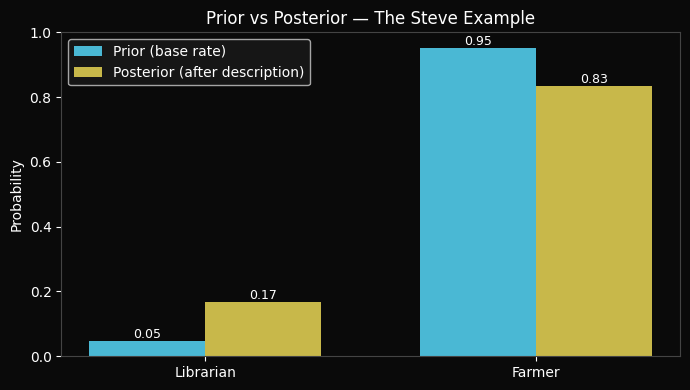

In [5]:
import matplotlib.pyplot as plt

labels = ['Librarian', 'Farmer']
prior     = [P_librarian, P_farmer]
posterior = [P_lib_final, P_farm_final]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')

bars1 = ax.bar([i - width/2 for i in x], prior,     width, label='Prior (base rate)',            color='#4ab8d4')
bars2 = ax.bar([i + width/2 for i in x], posterior, width, label='Posterior (after description)', color='#c8b84a')

ax.set_ylabel('Probability', color='white')
ax.set_title('Prior vs Posterior — The Steve Example', color='white')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.spines[:].set_color('#444')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', color='white', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()